<a href="https://colab.research.google.com/github/lc21140665-lgtm/Analisis-y-visualizacion-de-datos/blob/main/practica_bi_datamex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
ACTIVIDAD 1.1

In [2]:
# R Script
## ── SECCIÓN I: PIPELINE ETL
## Instala los paquetes si no los tienes:
install.packages(c("tidyverse", "lubridate", "writexl", "scales","DBI"))
library(tidyverse)
library(lubridate)
library(scales)
library(writexl)
library(DBI)

## ── 1. EXTRACT: Generar dataset con errores intencionales ──────────────
set.seed(42)
n <- 500
ventas_raw <- tibble(
id_venta = 1:n,
fecha_venta = sample(c(
format(seq(as.Date("2024-01-01"), as.Date("2024-12-31"), by="day"),
c("%d/%m/%Y", "%Y-%m-%d")[sample(1:2, 366, replace=TRUE)]),
NA_character_), n, replace=TRUE),
id_producto = sample(paste0("P", sprintf("%03d", 1:30)), n,
replace=TRUE),
producto = sample(c("Laptop", "LAPTOP", "laptop",
"Silla", "SILLA",
"Playera", "playera",
"Cereal", "CEREAL",
"Televisor", "televisor"), n, replace=TRUE),
categoria = sample(c("Electrónico", "Hogar", "Ropa",
                     "Alimento", NA_character_), n,
replace=TRUE, prob=c(.25,.25,.2,.2,.1)),
region = sample(c("Norte","Sur","Centro",
"Occidente","Oriente"), n, replace=TRUE),
vendedor = sample(c("Ana López","ana lopez","ANA LOPEZ",
"Carlos Ruiz","carlos ruiz",
"María Torres", "Javier Soto"), n,
replace=TRUE),
cantidad = sample(c(1:50, -5, -10, 0), n, replace=TRUE),
precio_unitario = sample(c(100, 250, 500, 1200, 3500, 8000,
"$1500", "$250", NA_character_), n,
replace=TRUE),
descuento_pct = sample(c(0,5,10,15,20,25,30,NA_real_), n,
replace=TRUE),
canal_venta = sample(c("Online","Tienda","Distribuidor",
NA_character_), n, replace=TRUE)
)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [ ]:
ACTIVIDAD 1.2

In [3]:
## ── 1.2 Diagnóstico inicial (Profile) ─────────────────────────────────
glimpse(ventas_raw)
summary(ventas_raw)
# Conteo de valores nulos por columna
ventas_raw %>%
summarise(across(everything(), ~sum(is.na(.)))) %>%
pivot_longer(everything(), names_to="columna", values_to="nulos") %>%
arrange(desc(nulos)) %>%
print()

Rows: 500
Columns: 11
$ id_venta        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ fecha_venta     <chr> "01/08/2024", "10/11/2024", "2024-04-22", "30/01/2024"…
$ id_producto     <chr> "P027", "P008", "P012", "P012", "P012", "P015", "P009"…
$ producto        <chr> "Televisor", "SILLA", "Cereal", "Televisor", "Playera"…
$ categoria       <chr> "Hogar", NA, NA, "Hogar", "Alimento", NA, "Ropa", "Ali…
$ region          <chr> "Sur", "Sur", "Norte", "Oriente", "Centro", "Sur", "Or…
$ vendedor        <chr> "Carlos Ruiz", "ANA LOPEZ", "Ana López", "ana lopez", …
$ cantidad        <dbl> 46, 29, 25, 14, 13, 1, 11, 35, 14, 24, 42, 43, 26, 37,…
$ precio_unitario <chr> "250", "8000", NA, "8000", "$250", NA, "1200", "1200",…
$ descuento_pct   <dbl> 25, 5, 30, NA, NA, 5, 20, 0, 5, 15, 10, NA, NA, 25, NA…
$ canal_venta     <chr> "Distribuidor", "Distribuidor", "Distribuidor", "Tiend…


    id_venta     fecha_venta        id_producto          producto        
 Min.   :  1.0   Length:500         Length:500         Length:500        
 1st Qu.:125.8   Class :character   Class :character   Class :character  
 Median :250.5   Mode  :character   Mode  :character   Mode  :character  
 Mean   :250.5                                                           
 3rd Qu.:375.2                                                           
 Max.   :500.0                                                           
                                                                         
  categoria            region            vendedor            cantidad     
 Length:500         Length:500         Length:500         Min.   :-10.00  
 Class :character   Class :character   Class :character   1st Qu.: 12.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 25.00  
                                                          Mean   : 24.42  
                                 

# A tibble: 11 × 2
   columna         nulos
   <chr>           <int>
 1 canal_venta       120
 2 descuento_pct      67
 3 precio_unitario    54
 4 categoria          50
 5 fecha_venta         1
 6 id_venta            0
 7 id_producto         0
 8 producto            0
 9 region              0
10 vendedor            0
11 cantidad            0


SECCION II

In [ ]:
ACTIVIDAD 1.3 LIMPIEZA Y TRANSFORMACIÓN

In [4]:
## ── SECCIÓN II: LIMPIEZA Y TRANSFORMACIÓN ────────────────────────────
library(lubridate)
library(stringr)
ventas_limpio <- ventas_raw %>%
## ── 2.1 Corregir fechas con formatos mixtos ──────────────────────
mutate(fecha_venta = parse_date_time(fecha_venta,
orders = c("dmy", ";ymd"),
quiet = TRUE) %>% as.Date()) %>%
## 2.2 Convertir precio_unitario a numérico ─────────────────────
mutate(precio_unitario = as.numeric(str_remove(precio_unitario, "\\$"))) %>%
## ── 2.3 Eliminar registros con cantidad <= 0 ─────────────────────
filter(cantidad > 0) %>%
## ── 2.4 Estandarizar texto (mayúsculas iniciales) ────────────────
mutate(
producto = str_to_title(producto),
vendedor = str_to_title(vendedor),
categoria = str_to_title(categoria)
) %>%
## ── 2.5 Imputar valores faltantes ────────────────────────────────
mutate(
categoria = replace_na(categoria, "Sin Categoría"),
canal_venta = replace_na(canal_venta, "Desconocido"),
descuento_pct = replace_na(descuento_pct, 0)
) %>%
## ── 2.6 Crear columnas calculadas ────────────────────────────────
mutate(
venta_bruta = cantidad * precio_unitario,
descuento_monto = venta_bruta * (descuento_pct / 100),
venta_neta = venta_bruta - descuento_monto,
mes = month(fecha_venta, label = TRUE, abbr = FALSE),
trimestre = paste0("Q", quarter(fecha_venta)),
anio = year(fecha_venta)
) %>%
## ── 2.7 Eliminar duplicados exactos ──────────────────────────────
distinct()
cat("✅ TRANSFORM completado:", nrow(ventas_limpio), "registros válidos\n")
cat("Registros eliminados:", nrow(ventas_raw) - nrow(ventas_limpio),
"\n")

✅ TRANSFORM completado: 473 registros válidos
Registros eliminados: 27 


In [5]:
sum(ventas_raw$cantidad <= 0, na.rm = TRUE)
sum(ventas_limpio$cantidad <= 0, na.rm = TRUE)
sum(is.na(ventas_raw$categoria))
sum(is.na(ventas_limpio$categoria))
sum(duplicated(ventas_raw))
sum(duplicated(ventas_limpio))

[1] 27

[1] 0

[1] 50

[1] 0

[1] 0

[1] 0

In [6]:
ventas_limpio %>%
  distinct(vendedor) %>%
  arrange(vendedor)


vendedor
<chr>
Ana Lopez
Ana López
Carlos Ruiz
Javier Soto
María Torres


In [7]:
ventas_limpio %>%
  filter(venta_neta < 0)

id_venta,fecha_venta,id_producto,producto,categoria,region,vendedor,cantidad,precio_unitario,descuento_pct,canal_venta,venta_bruta,descuento_monto,venta_neta,mes,trimestre,anio
<int>,<date>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<ord>,<chr>,<dbl>


SECCION III

In [8]:
# R Script
## ── SECCIÓN III: MODELO ESTRELLA ─────────────────────────────────────

## ── DIM_FECHA ──────────────────────────────────────────────────────
dim_fecha <- ventas_limpio %>%
  select(fecha_venta) %>%
  distinct() %>%
  mutate(
    id_fecha    = row_number(),
    dia         = day(fecha_venta),
    mes         = month(fecha_venta, label=TRUE, abbr=FALSE),
    mes_num     = month(fecha_venta),
    trimestre   = paste0("Q", quarter(fecha_venta)),
    anio        = year(fecha_venta),
    dia_semana  = wday(fecha_venta, label=TRUE, abbr=FALSE, locale="es_MX")
  ) %>%
  rename(fecha = fecha_venta)

## ── DIM_PRODUCTO ─────────────────────────────────────────────────
dim_producto <- ventas_limpio %>%
  select(id_producto, producto, categoria) %>%
  distinct(id_producto, .keep_all = TRUE)

## ── DIM_VENDEDOR ─────────────────────────────────────────────────
dim_vendedor <- ventas_limpio %>%
  select(vendedor) %>%
  distinct() %>%
  mutate(id_vendedor = row_number())

## ── DIM_REGION ───────────────────────────────────────────────────
dim_region <- ventas_limpio %>%
  select(region) %>%
  distinct() %>%
  mutate(id_region = row_number())

## ── DIM_CANAL ────────────────────────────────────────────────────
dim_canal <- ventas_limpio %>%
  select(canal_venta) %>%
  distinct() %>%
  mutate(id_canal = row_number())

## ── FACT_VENTAS: unir todas las claves ───────────────────────────
fact_ventas <- ventas_limpio %>%
  left_join(dim_fecha,    by = c("fecha_venta" = "fecha")) %>%
  left_join(dim_vendedor, by = "vendedor") %>%
  left_join(dim_region,   by = "region") %>%
  left_join(dim_canal,    by = "canal_venta") %>%
  select(id_venta, id_producto, id_vendedor, id_fecha,
         id_region, id_canal, cantidad, precio_unitario,
         descuento_pct, venta_bruta, venta_neta)

cat("✅ Modelo Estrella construido\n")
cat("   FACT_VENTAS:", nrow(fact_ventas), "filas x", ncol(fact_ventas), "columnas\n")
cat("   DIM_FECHA:", nrow(dim_fecha), "fechas únicas\n")
cat("   DIM_PRODUCTO:", nrow(dim_producto), "productos únicos\n")


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `dia_semana = wday(fecha_venta, label = TRUE, abbr = FALSE,
  locale = "es_MX")`.
Caused by warning in `Sys.setlocale()`:
! OS reports request to set locale to "es_MX" cannot be honored”


✅ Modelo Estrella construido
   FACT_VENTAS: 473 filas x 11 columnas
   DIM_FECHA: 282 fechas únicas
   DIM_PRODUCTO: 30 productos únicos


SECCION IV

In [9]:
# R Script
## ── SECCIÓN IV: KPIs E INTELIGENCIA DE NEGOCIOS ─────────────────────

## ── KPI 1: Resumen general ──────────────────────────────────────────
kpi_general <- ventas_limpio %>%
  summarise(
    ventas_totales    = sum(venta_neta, na.rm = TRUE),
    ticket_promedio   = mean(venta_neta, na.rm = TRUE),
    tasa_descuento    = mean(descuento_pct, na.rm = TRUE),
    total_transacc    = n(),
    unidades_totales  = sum(cantidad, na.rm = TRUE)
  )
print(kpi_general)

## ── KPI 2: Ventas por región ─────────────────────────────────────────
kpi_region <- ventas_limpio %>%
  group_by(region) %>%
  summarise(
    ventas = sum(venta_neta, na.rm = TRUE),
    trans  = n()
  ) %>%
  mutate(participacion_pct = ventas / sum(ventas) * 100) %>%
  arrange(desc(ventas))
print(kpi_region)

## ── KPI 3: Ventas por mes ────────────────────────────────────────────
kpi_mensual <- ventas_limpio %>%
  group_by(anio, trimestre, mes) %>%
  summarise(ventas = sum(venta_neta, na.rm = TRUE), .groups = "drop") %>%
  arrange(anio, trimestre)
print(kpi_mensual)

## ── KPI 4: Top 5 productos ───────────────────────────────────────────
top5_productos <- ventas_limpio %>%
  group_by(producto, categoria) %>%
  summarise(ventas = sum(venta_neta, na.rm = TRUE), .groups = "drop") %>%
  slice_max(ventas, n = 5)
print(top5_productos)
## ── KPI 5: Performance de vendedores ────────────────────────────────
kpi_vendedor <- ventas_limpio %>%
  group_by(vendedor) %>%
  summarise(
    ventas          = sum(venta_neta, na.rm = TRUE),
    transacciones   = n(),
    ticket_promedio = mean(venta_neta, na.rm = TRUE)
  ) %>%
  arrange(desc(ventas))
print(kpi_vendedor)

## ── KPI 6: Crecimiento MoM (Month over Month) ───────────────────────
kpi_mom <- kpi_mensual %>%
  mutate(
    ventas_anterior = lag(ventas),
    crecimiento_pct = (ventas - ventas_anterior) / ventas_anterior * 100
  )
print(kpi_mom)


# A tibble: 1 × 5
  ventas_totales ticket_promedio tasa_descuento total_transacc unidades_totales
           <dbl>           <dbl>          <dbl>          <int>            <dbl>
1       19215930          45428.           12.6            473            12348
# A tibble: 5 × 4
  region      ventas trans participacion_pct
  <chr>        <dbl> <int>             <dbl>
1 Occidente 4273282.    99              22.2
2 Oriente   3975800     96              20.7
3 Sur       3774272.    95              19.6
4 Norte     3600858.    99              18.7
5 Centro    3591718.    84              18.7
# A tibble: 13 × 4
    anio trimestre mes         ventas
   <dbl> <chr>     <ord>        <dbl>
 1  2024 Q1        January   1127450 
 2  2024 Q1        February  1959258.
 3  2024 Q1        March     1494125 
 4  2024 Q2        April     1215482.
 5  2024 Q2        May       1105282.
 6  2024 Q2        June      3073518.
 7  2024 Q3        July      1372785 
 8  2024 Q3        August    1885862.
 9  2024 Q

SECCION 5

In [10]:
install.packages(c("ggplot2", "scales"))
library(ggplot2)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


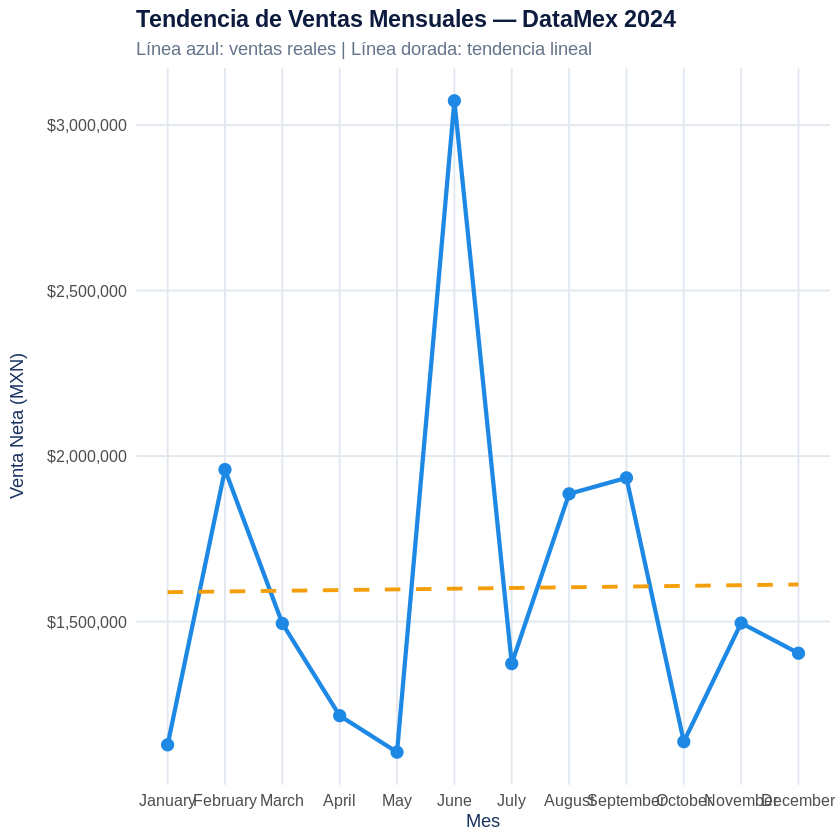

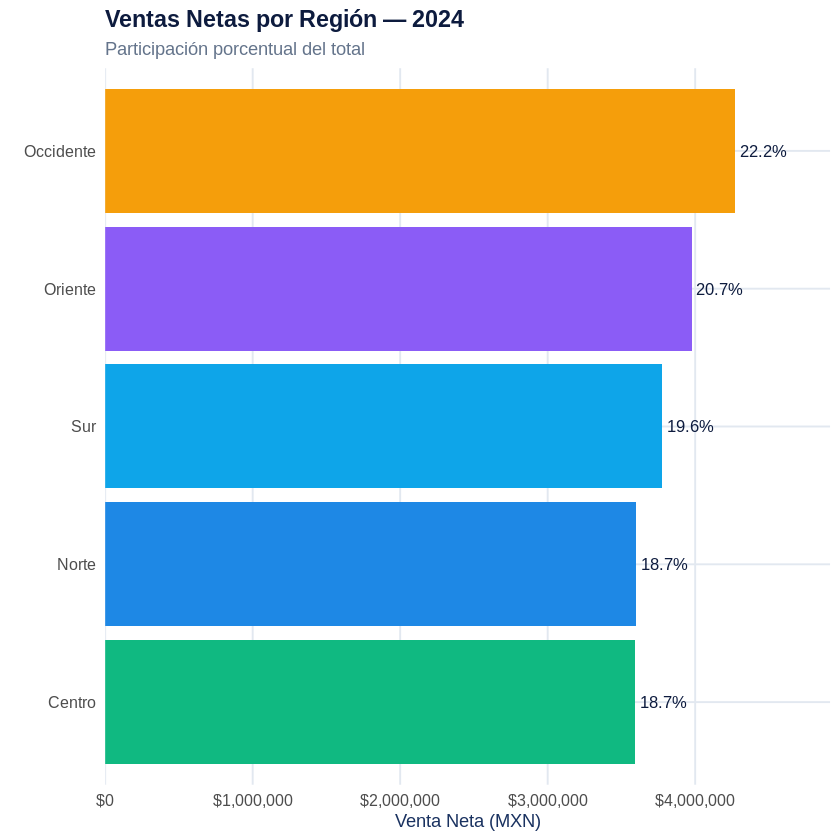

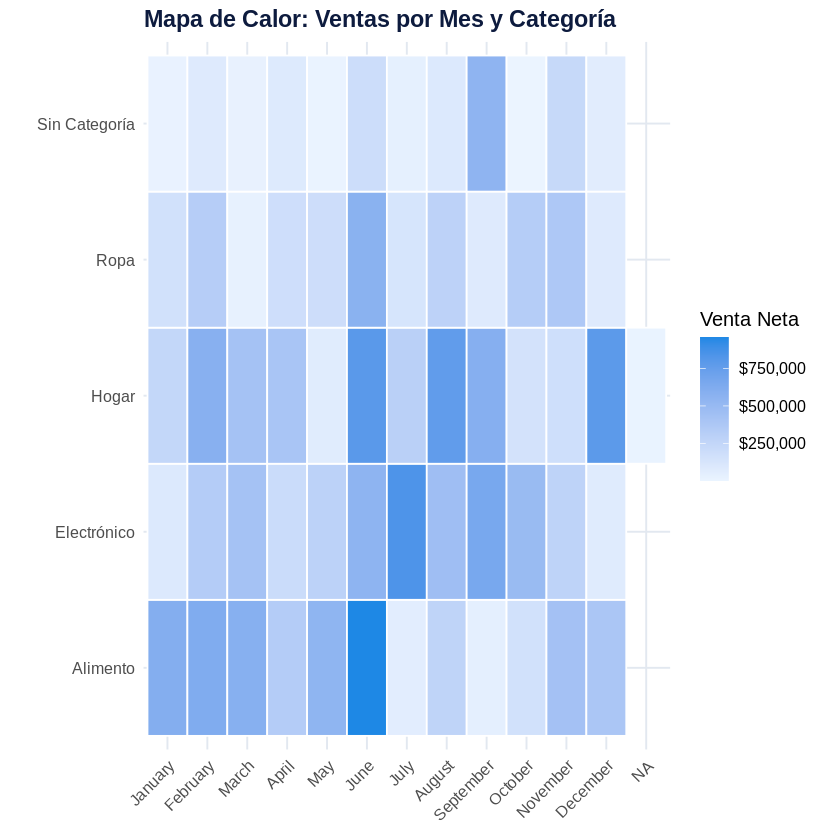

In [12]:
# R Script
## ── SECCIÓN V: VISUALIZACIÓN CON GGPLOT2 ────────────────────────────
library(ggplot2)
library(scales)    # para format_number, dollar, percent

## ── Tema corporativo DataMex ─────────────────────────────────────────
tema_datamex <- theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face="bold", color="#0D1B3E", size=14),
    plot.subtitle = element_text(color="#64748B", size=11),
    axis.title    = element_text(color="#1A3260", size=11),
    panel.grid.major = element_line(color="#E2E8F0"),
    panel.grid.minor = element_blank()
  )

## ── Gráfico 1: Ventas mensuales (línea de tendencia) ─────────────────
kpi_mensual_plot_data <- kpi_mensual %>%
  filter(!is.na(mes)) %>%
  mutate(mes_n = row_number())

g1 <- kpi_mensual_plot_data %>%
  ggplot(aes(x = mes_n, y = ventas)) +
  geom_line(color = "#1E88E5", linewidth = 1.2) +
  geom_point(color = "#1E88E5", size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "#F59E0B", linetype = 2) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  scale_x_continuous(breaks = 1:nrow(kpi_mensual_plot_data), labels = kpi_mensual_plot_data$mes) + # Use kpi_mensual_plot_data
  labs(
    title    = "Tendencia de Ventas Mensuales — DataMex 2024",
    subtitle = "Línea azul: ventas reales | Línea dorada: tendencia lineal",
    x = "Mes", y = "Venta Neta (MXN)"
  ) + tema_datamex
print(g1)
ggsave("grafico1_tendencia_mensual.png", g1, width=10, height=5, dpi=150)

## ── Gráfico 2: Ventas por región (barras horizontales) ───────────────
g2 <- kpi_region %>%
  ggplot(aes(x = reorder(region, ventas), y = ventas, fill = region)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0(round(participacion_pct,1), "%")),
            hjust = -0.1, size = 3.5, color = "#0D1B3E") +
  coord_flip() +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ","),
                     expand = expansion(mult = c(0, .15))) +
  scale_fill_manual(values = c("Norte"="#1E88E5", "Sur"="#0EA5E9",
                               "Centro"="#10B981", "Occidente"="#F59E0B",
                               "Oriente"="#8B5CF6")) +
  labs(title = "Ventas Netas por Región — 2024",
       subtitle = "Participación porcentual del total",
       x = NULL, y = "Venta Neta (MXN)") + tema_datamex
print(g2)
ggsave("grafico2_ventas_region.png", g2, width=8, height=5, dpi=150)

## ── Gráfico 3: Heatmap de ventas por mes y categoría ────────────────
g3 <- ventas_limpio %>%
  group_by(mes, categoria) %>%
  summarise(ventas = sum(venta_neta, na.rm=TRUE), .groups="drop") %>%
  ggplot(aes(x = mes, y = categoria, fill = ventas)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient(low = "#EBF4FF", high = "#1E88E5",
                      labels = dollar_format(prefix="$", big.mark=",")) +
  labs(title = "Mapa de Calor: Ventas por Mes y Categoría",
       x = NULL, y = NULL, fill = "Venta Neta") + tema_datamex +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
print(g3)
ggsave("grafico3_heatmap.png", g3, width=10, height=5, dpi=150)

Warning message:
“Removed 50 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


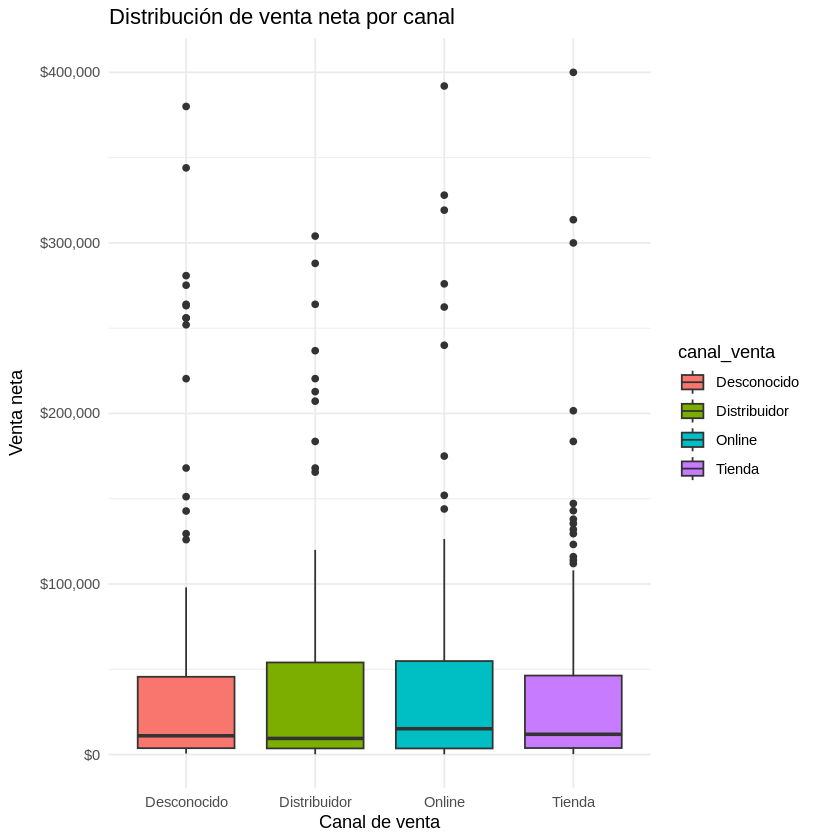

In [13]:
library(ggplot2)
ggplot(ventas_limpio, aes(x = canal_venta, y = venta_neta, fill = canal_venta)) +
  geom_boxplot() +
  scale_y_continuous(labels = scales::dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Distribución de venta neta por canal",
    x = "Canal de venta",
    y = "Venta neta"
  ) +
  theme_minimal()

SECCION VI. Regresión lineal


=== MATRIZ DE CORRELACIÓN ===
                venta_neta cantidad descuento_pct precio_unitario
venta_neta           1.000    0.339        -0.064           0.840
cantidad             0.339    1.000        -0.095           0.034
descuento_pct       -0.064   -0.095         1.000           0.020
precio_unitario      0.840    0.034         0.020           1.000

=== MODELO SIMPLE ===



Call:
lm(formula = venta_neta ~ cantidad, data = datos_reg)

Residuals:
   Min     1Q Median     3Q    Max 
-81360 -38498 -15382   7700 312708 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -1065.1     7124.7  -0.149    0.881    
cantidad      1767.1      238.9   7.396 7.66e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 68970 on 421 degrees of freedom
Multiple R-squared:  0.115,	Adjusted R-squared:  0.1129 
F-statistic:  54.7 on 1 and 421 DF,  p-value: 7.659e-13



=== MODELO MÚLTIPLE ===



Call:
lm(formula = venta_neta ~ cantidad + descuento_pct + precio_unitario, 
    data = datos_reg)

Residuals:
    Min      1Q  Median      3Q     Max 
-126173  -15587    -972   13448  168122 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -3.805e+04  4.096e+03  -9.289   <2e-16 ***
cantidad         1.596e+03  1.129e+02  14.130   <2e-16 ***
descuento_pct   -3.507e+02  1.492e+02  -2.351   0.0192 *  
precio_unitario  2.377e+01  6.172e-01  38.512   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 32430 on 419 degrees of freedom
Multiple R-squared:  0.8053,	Adjusted R-squared:  0.8039 
F-statistic: 577.6 on 3 and 419 DF,  p-value: < 2.2e-16



=== MÉTRICAS DE EVALUACIÓN ===
# A tibble: 1 × 4
  R_cuadrado R2_ajustado   RMSE    MAE
       <dbl>       <dbl>  <dbl>  <dbl>
1      0.805       0.804 32275. 20901.

=== PRONÓSTICOS DE VENTA ===
# A tibble: 4 × 4
  cantidad descuento_pct precio_unitario venta_predicha
     <dbl>         <dbl>           <dbl>          <dbl>
1       10             0             500        -10205.
2       25            10            1200         26860.
3       50            20            3500        117910.
4      100            30            8000        301140.


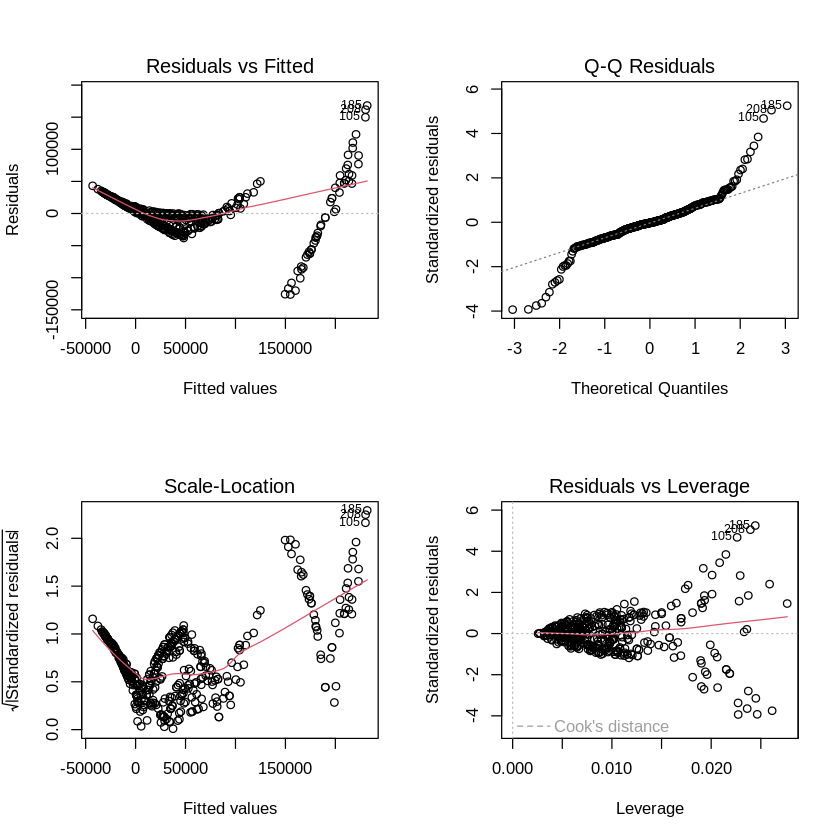

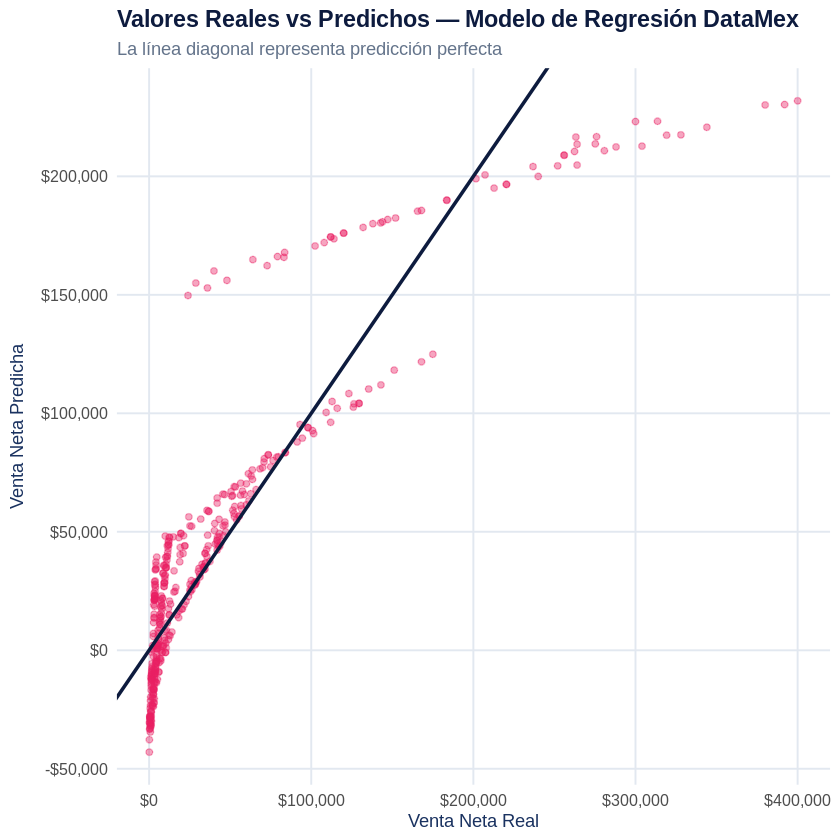

In [14]:
# R Script
## ── SECCIÓN VI: ANÁLISIS PREDICTIVO — REGRESIÓN ─────────────────────

## ── 6.1 Preparar dataset numérico ───────────────────────────────────
datos_reg <- ventas_limpio %>%
  select(venta_neta, cantidad, descuento_pct, precio_unitario) %>%
  drop_na()

## ── 6.2 Análisis de correlación ──────────────────────────────────────
cat("\n=== MATRIZ DE CORRELACIÓN ===\n")
print(round(cor(datos_reg), 3))

## ── 6.3 Regresión Lineal Simple: venta_neta ~ cantidad ───────────────
modelo_simple <- lm(venta_neta ~ cantidad, data = datos_reg)
cat("\n=== MODELO SIMPLE ===\n")
summary(modelo_simple)

## ── 6.4 Regresión Lineal Múltiple ────────────────────────────────────
modelo_multiple <- lm(venta_neta ~ cantidad + descuento_pct + precio_unitario,
                      data = datos_reg)
cat("\n=== MODELO MÚLTIPLE ===\n")
summary(modelo_multiple)

## ── 6.5 Métricas de evaluación ───────────────────────────────────────
predicciones <- predict(modelo_multiple, datos_reg)
residuos     <- datos_reg$venta_neta - predicciones
metricas <- tibble(
  R_cuadrado = summary(modelo_multiple)$r.squared,
  R2_ajustado = summary(modelo_multiple)$adj.r.squared,
  RMSE = sqrt(mean(residuos^2)),
  MAE  = mean(abs(residuos))
)
cat("\n=== MÉTRICAS DE EVALUACIÓN ===\n")
print(metricas)

## ── 6.6 Diagnóstico visual del modelo ────────────────────────────────
par(mfrow = c(2, 2))
plot(modelo_multiple)
par(mfrow = c(1, 1))

## ── 6.7 Predicción para nuevos datos ────────────────────────────────
nuevos_clientes <- tibble(
  cantidad       = c(10,  25,  50,  100),
  descuento_pct  = c(0,   10,  20,   30),
  precio_unitario = c(500, 1200, 3500, 8000)
)

nuevos_clientes$venta_predicha <- predict(modelo_multiple, nuevos_clientes)
cat("\n=== PRONÓSTICOS DE VENTA ===\n")
print(nuevos_clientes)

## ── 6.8 Gráfico de valores reales vs predichos ───────────────────────
tibble(real = datos_reg$venta_neta, predicho = predicciones) %>%
  ggplot(aes(x = real, y = predicho)) +
  geom_point(alpha = 0.4, color = "#E91E63", size = 1.5) +
  geom_abline(slope = 1, intercept = 0, color = "#0D1B3E", linewidth = 1) +
  scale_x_continuous(labels = dollar_format(prefix="$", big.mark=",")) +
  scale_y_continuous(labels = dollar_format(prefix="$", big.mark=",")) +
  labs(
    title    = "Valores Reales vs Predichos — Modelo de Regresión DataMex",
    subtitle = "La línea diagonal representa predicción perfecta",
    x = "Venta Neta Real", y = "Venta Neta Predicha"
  ) + tema_datamex


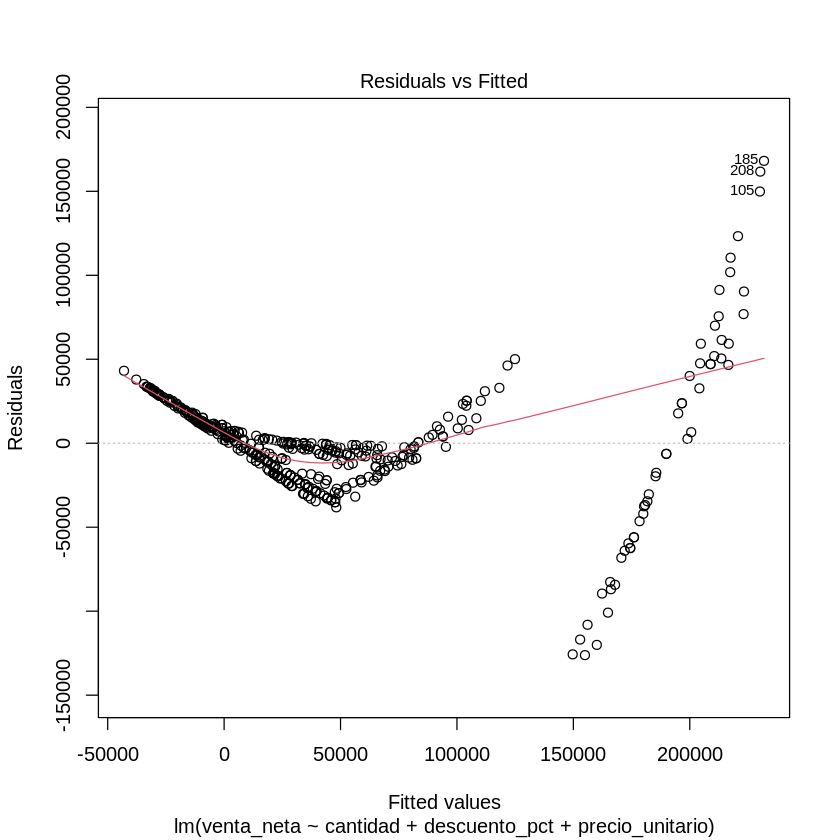

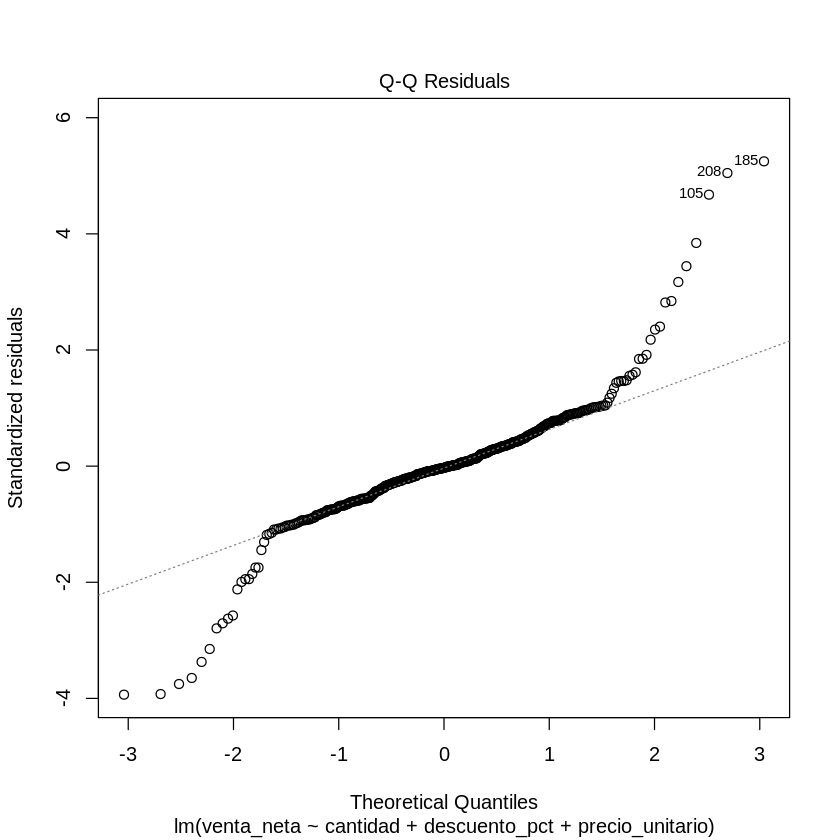

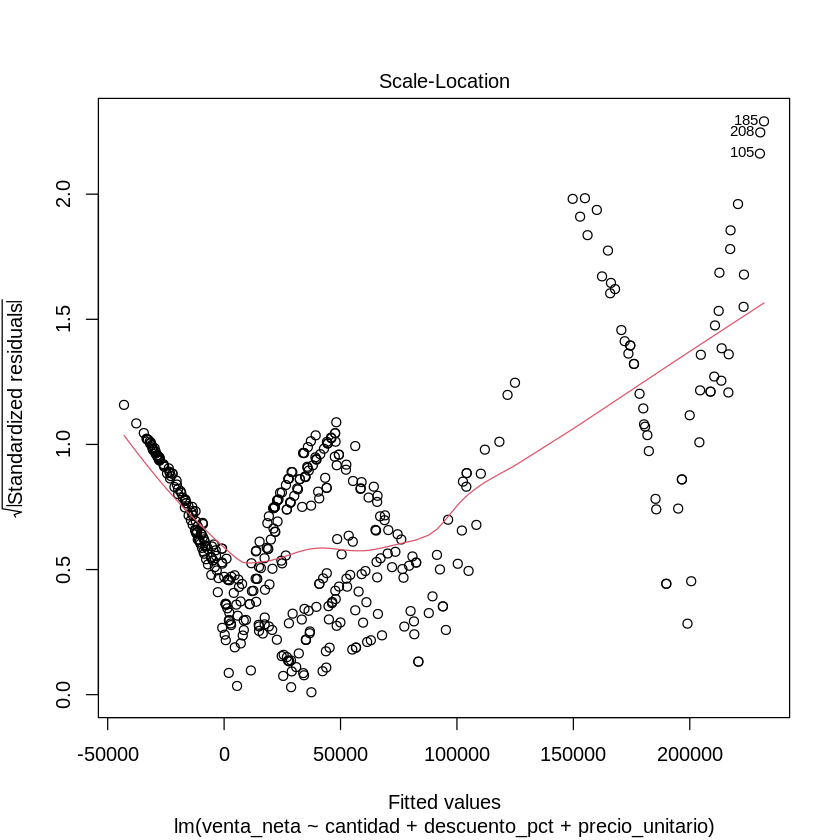

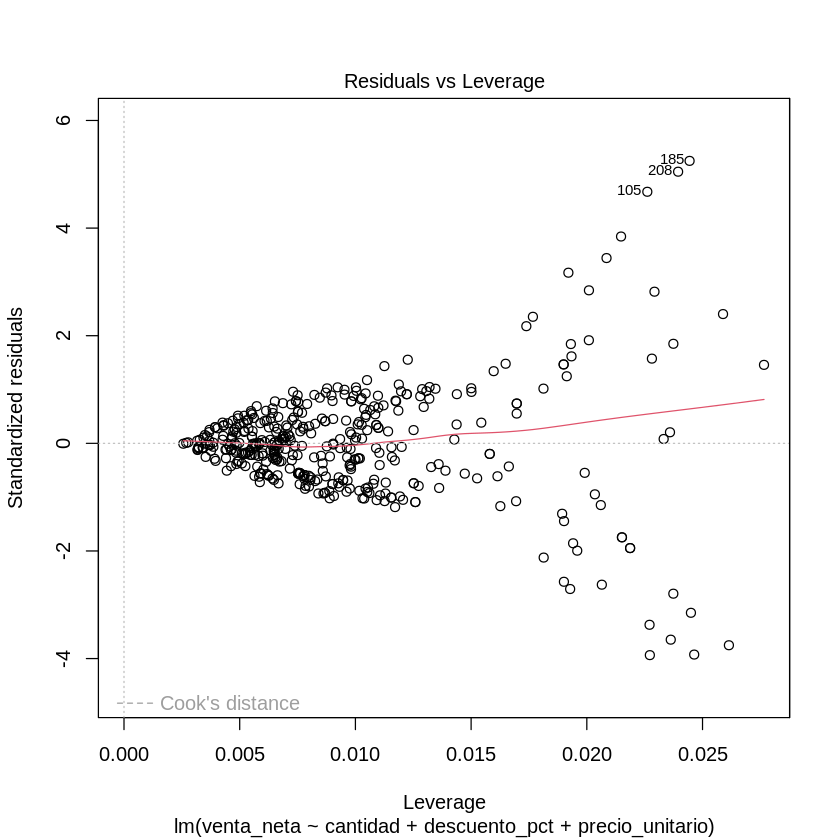

In [15]:
plot(modelo_multiple)

In [16]:
summary(modelo_simple)
summary(modelo_multiple)
metricas


Call:
lm(formula = venta_neta ~ cantidad, data = datos_reg)

Residuals:
   Min     1Q Median     3Q    Max 
-81360 -38498 -15382   7700 312708 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -1065.1     7124.7  -0.149    0.881    
cantidad      1767.1      238.9   7.396 7.66e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 68970 on 421 degrees of freedom
Multiple R-squared:  0.115,	Adjusted R-squared:  0.1129 
F-statistic:  54.7 on 1 and 421 DF,  p-value: 7.659e-13



Call:
lm(formula = venta_neta ~ cantidad + descuento_pct + precio_unitario, 
    data = datos_reg)

Residuals:
    Min      1Q  Median      3Q     Max 
-126173  -15587    -972   13448  168122 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -3.805e+04  4.096e+03  -9.289   <2e-16 ***
cantidad         1.596e+03  1.129e+02  14.130   <2e-16 ***
descuento_pct   -3.507e+02  1.492e+02  -2.351   0.0192 *  
precio_unitario  2.377e+01  6.172e-01  38.512   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 32430 on 419 degrees of freedom
Multiple R-squared:  0.8053,	Adjusted R-squared:  0.8039 
F-statistic: 577.6 on 3 and 419 DF,  p-value: < 2.2e-16


R_cuadrado,R2_ajustado,RMSE,MAE
<dbl>,<dbl>,<dbl>,<dbl>
0.8052755,0.8038813,32274.51,20901.15


In [17]:
nuevo_escenario <- tibble(
  cantidad = 75,
  descuento_pct = 15,
  precio_unitario = 2000
)

predict(modelo_multiple, nuevo_escenario)

1 
123902.3